In [7]:

import os
import glob
import cv2
import numpy as np
from tqdm import tqdm

OUT_TRAIN_IMG = "/kaggle/working/patches/train/images"
OUT_TRAIN_MASK = "/kaggle/working/patches/train/masks"
OUT_VAL_IMG = "/kaggle/working/patches/val/images"
OUT_VAL_MASK = "/kaggle/working/patches/val/masks"

os.makedirs(OUT_TRAIN_IMG, exist_ok=True)
os.makedirs(OUT_TRAIN_MASK, exist_ok=True)
os.makedirs(OUT_VAL_IMG, exist_ok=True)
os.makedirs(OUT_VAL_MASK, exist_ok=True)

# Find train directory
TRAIN_IMAGES_DIR = glob.glob("/kaggle/input/**/train/images", recursive=True)[0]
TRAIN_MASKS_DIR = os.path.join(os.path.dirname(TRAIN_IMAGES_DIR), "gt")

image_files = sorted(glob.glob(os.path.join(TRAIN_IMAGES_DIR, "*.tif")))

PATCH_SIZE = 512
STRIDE = 512

print("Pre-cropping 5000x5000 tiles into 512x512 PNGs on disk...")

patch_count = 0
for img_path in tqdm(image_files, desc="Processing Tiles"):
    filename = os.path.basename(img_path)
    mask_path = os.path.join(TRAIN_MASKS_DIR, filename)
    
    if not os.path.isfile(mask_path):
        continue
        
    is_val = "vienna" in filename.lower()
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None or mask is None:
        continue
        
    base_name = os.path.splitext(filename)[0]
    
    for y in range(0, 5000 - PATCH_SIZE + 1, STRIDE):
        for x in range(0, 5000 - PATCH_SIZE + 1, STRIDE):
            img_crop = img[y:y+512, x:x+512]
            mask_crop = mask[y:y+512, x:x+512]
            
            patch_name = f"{base_name}_{y}_{x}.png"
            
            if is_val:
                cv2.imwrite(os.path.join(OUT_VAL_IMG, patch_name), img_crop)
                cv2.imwrite(os.path.join(OUT_VAL_MASK, patch_name), mask_crop)
            else:
                cv2.imwrite(os.path.join(OUT_TRAIN_IMG, patch_name), img_crop)
                cv2.imwrite(os.path.join(OUT_TRAIN_MASK, patch_name), mask_crop)
                
            patch_count += 1

print(f"Done! Saved {patch_count} patches to disk.")


Pre-cropping 5000x5000 tiles into 512x512 PNGs on disk...


Processing Tiles:   0%|          | 0/180 [00:00<?, ?it/s][ WARN:0@12638.724] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@12638.724] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@12638.724] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@12638.724] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@12638.885] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@12638.885] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@12638.885] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@12638.885] global grfmt_tiff.cpp:122 T

Done! Saved 14580 patches to disk.


In [12]:

import os
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

class DirectPNGDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_paths = sorted(glob.glob(os.path.join(img_dir, "*.png")))
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        filename = os.path.basename(img_path)
        mask_path = os.path.join(self.mask_dir, filename)
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        return img, mask.unsqueeze(0)

train_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_dataset = DirectPNGDataset("/kaggle/working/patches/train/images", "/kaggle/working/patches/train/masks", transform=train_transform)
val_dataset = DirectPNGDataset("/kaggle/working/patches/val/images", "/kaggle/working/patches/val/masks", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"DataLoaders Ready | Train Patches: {len(train_dataset)} | Val Patches: {len(val_dataset)}")


DataLoaders Ready | Train Patches: 11664 | Val Patches: 2916


In [ ]:

import gc
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device} ({torch.cuda.get_device_name(0)})")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

class CombinedBCEDiceLoss(nn.Module):
    def __init__(self):
        super(CombinedBCEDiceLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(mode="binary", from_logits=True)

    def forward(self, y_pred, y_true):
        return self.bce(y_pred, y_true) + self.dice(y_pred, y_true)

criterion = CombinedBCEDiceLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scaler = GradScaler()

def calculate_metrics(pred_mask, true_mask, threshold=0.5):
    pred_binary = (torch.sigmoid(pred_mask) > threshold).float()
    intersection = (pred_binary * true_mask).sum()
    union = pred_binary.sum() + true_mask.sum() - intersection
    iou = (intersection + 1e-7) / (union + 1e-7)
    dice = (2.0 * intersection + 1e-7) / (pred_binary.sum() + true_mask.sum() + 1e-7)
    return iou.item(), dice.item()

epochs = 3
best_val_iou = 0.0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for step, (images, masks) in enumerate(pbar):
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
        
    avg_train_loss = train_loss / len(train_loader)
    
    # Validation Loop
    model.eval()
    val_loss, val_iou, val_dice = 0.0, 0.0, 0.0
    
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val - Vienna]"):
            images, masks = images.to(device), masks.to(device)
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)
            
            val_loss += loss.item()
            iou, dice = calculate_metrics(outputs, masks)
            val_iou += iou
            val_dice += dice
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)
    
    print(f"\n--- Epoch {epoch+1} Results ---")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Val IoU (Jaccard): {avg_val_iou:.4f} | Val Dice (F1): {avg_val_dice:.4f}\n")
    
    if avg_val_iou > best_val_iou:
        best_val_iou = avg_val_iou
        torch.save(model.state_dict(), "/kaggle/working/best_unet_inria_model.pth")
        print(f"Saved Checkpoint! Best Val IoU: {best_val_iou:.4f}\n")
# === CELL 3 END ===

In [13]:
import os

checkpoint_path = "/kaggle/working/best_unet_inria_model.pth"

if os.path.exists(checkpoint_path):
    size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
    print(f"SUCCESS: Model weights found!")
    print(f"Path: {checkpoint_path}")
    print(f"File Size: {size_mb:.2f} MB")
else:
    print("No checkpoint found at /kaggle/working/best_unet_inria_model.pth")

SUCCESS: Model weights found!
Path: /kaggle/working/best_unet_inria_model.pth
File Size: 93.39 MB


Loaded model checkpoint successfully!


Evaluating Vienna Hold-out Set: 100%|██████████| 92/92 [00:41<00:00,  2.20it/s]


 VIENNA VALIDATION METRICS
 - Mean IoU (Jaccard Index): 0.6967
 - Mean Dice Score (F1):    0.8203



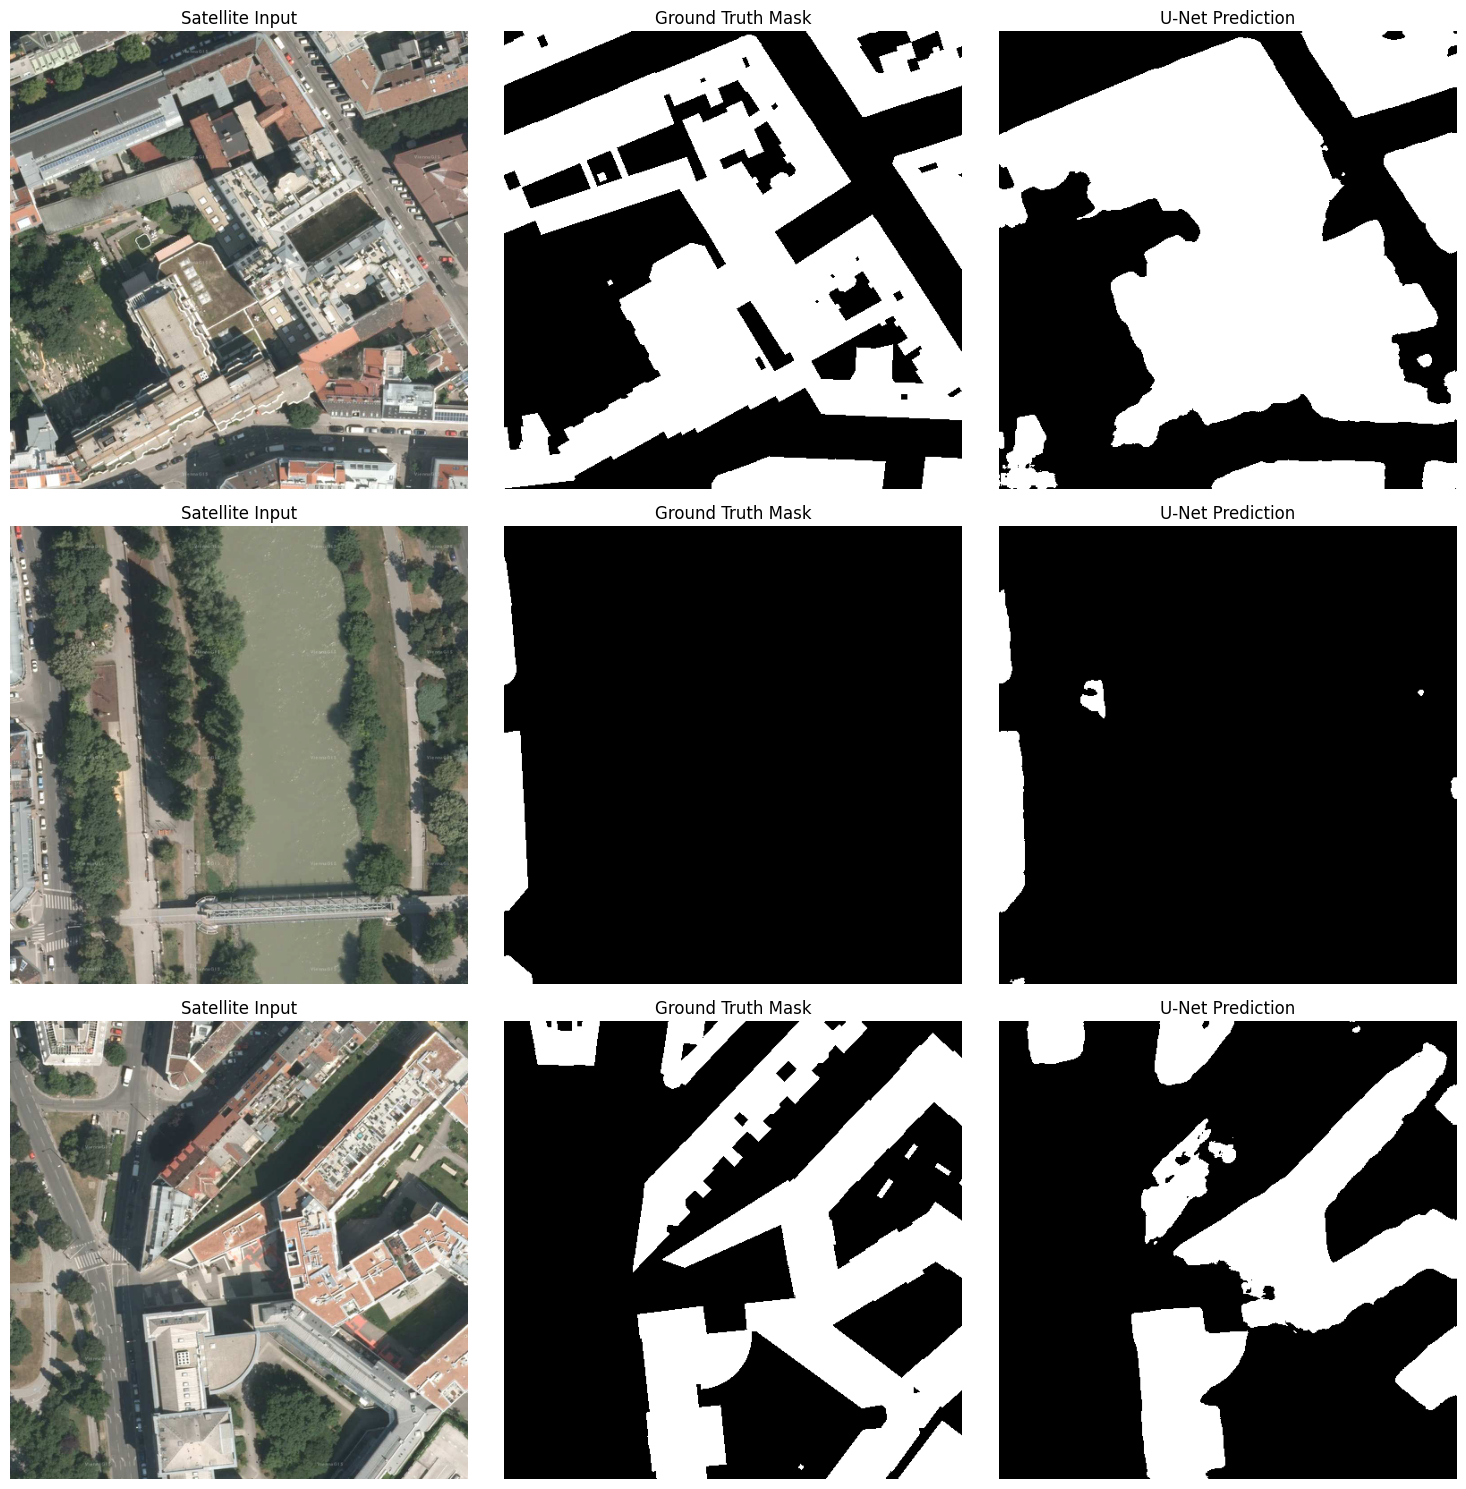

In [14]:

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = "/kaggle/working/best_unet_inria_model.pth"

# 1. Load Trained Model Checkpoint
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
).to(device)

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()
print("Loaded model checkpoint successfully!")

# 2. Compute Vienna Validation Performance
def calculate_metrics(pred_mask, true_mask, threshold=0.5):
    pred_binary = (torch.sigmoid(pred_mask) > threshold).float()
    intersection = (pred_binary * true_mask).sum()
    union = pred_binary.sum() + true_mask.sum() - intersection
    iou = (intersection + 1e-7) / (union + 1e-7)
    dice = (2.0 * intersection + 1e-7) / (pred_binary.sum() + true_mask.sum() + 1e-7)
    return iou.item(), dice.item()

val_iou, val_dice = 0.0, 0.0
with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Evaluating Vienna Hold-out Set"):
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        iou, dice = calculate_metrics(outputs, masks)
        val_iou += iou
        val_dice += dice

print(f"\n==========================================")
print(f" VIENNA VALIDATION METRICS")
print(f" - Mean IoU (Jaccard Index): {val_iou / len(val_loader):.4f}")
print(f" - Mean Dice Score (F1):    {val_dice / len(val_loader):.4f}")
print(f"==========================================\n")

# 3. Plot Visual Comparison (Input | Ground Truth | Prediction)
def plot_sample_predictions(model, dataloader, num_samples=3):
    model.eval()
    samples_plotted = 0
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    with torch.no_grad():
        for images, masks in dataloader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)
            preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
            
            for i in range(images.size(0)):
                if samples_plotted >= num_samples:
                    break
                
                # Denormalize image for display
                img = images[i].permute(1, 2, 0).numpy()
                img = std * img + mean
                img = np.clip(img, 0, 1)
                
                gt_mask = masks[i, 0].numpy()
                pred_mask = preds[i, 0]

                ax = axes[samples_plotted]
                ax[0].imshow(img)
                ax[0].set_title("Satellite Input")
                ax[0].axis("off")

                ax[1].imshow(gt_mask, cmap="gray")
                ax[1].set_title("Ground Truth Mask")
                ax[1].axis("off")

                ax[2].imshow(pred_mask, cmap="gray")
                ax[2].set_title("U-Net Prediction")
                ax[2].axis("off")

                samples_plotted += 1

            if samples_plotted >= num_samples:
                break

    plt.tight_layout()
    plt.show()

plot_sample_predictions(model, val_loader, num_samples=3)
